# S07-demo-02 – Mixed features pipeline: числовые + категориальные признаки

Этот ноутбук показывает, как **правильно строить preprocessing для смешанных табличных данных**:
числовые признаки обрабатываются одним путём, категориальные – другим, а затем всё собирается в единый `Pipeline`.

Цель семинара – не "выжать максимум качества", а понять инженерную логику:

- почему для mixed-features задач нужен `ColumnTransformer`;
- почему **категориальные признаки нельзя просто "забыть"**;
- почему `OneHotEncoder` обычно честнее для линейной модели, чем `OrdinalEncoder`;
- почему preprocessing должен быть частью модели, а не набором разрозненных действий "снаружи".

## Что вы здесь освоите

- как собрать синтетический, но реалистичный mixed-features датасет;
- как зафиксировать `train/test` и один раз выбрать гиперпараметр модели;
- как сравнить несколько схем подготовки **на одной и той же модели**;
- как посмотреть, какие признаки реально двигают решение логистической регрессии;
- как сохранить артефакты эксперимента в `artifacts/`.


## 0. Настройки, импорты, пути для артефактов

Мы заранее создаём папку `artifacts/` рядом с ноутбуком.  
Туда сохраним:

- таблицу итоговых результатов по вариантам preprocessing;
- сведения о reference-подборе гиперпараметра `C`;
- лучшую собранную pipeline-модель;
- небольшой JSON с метаданными;
- таблицу с наиболее сильными коэффициентами лучшей модели.

Это делает эксперимент **воспроизводимым**: у нас останутся не только графики на экране, но и файлы, с которыми можно работать дальше.


In [1]:

# Базовые настройки, импорты и папка для артефактов.
from pathlib import Path
import json

import joblib          # Сериализация sklearn-объектов (pipeline → файл)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.compose import ColumnTransformer   # Позволяет применять разные трансформеры к разным колонкам
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, RobustScaler, OrdinalEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    roc_auc_score,
    classification_report,
    ConfusionMatrixDisplay,  # Удобный helper для отрисовки confusion matrix прямо из estimator
)

RANDOM_STATE = 42
ARTIFACTS_DIR = Path("artifacts")
ARTIFACTS_DIR.mkdir(exist_ok=True)  # exist_ok=True: не бросает ошибку, если папка уже существует

# Увеличиваем ширину вывода таблиц, чтобы колонки не обрезались в Jupyter
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)


In [2]:

# Вспомогательные функции: генерация mixed-features датасета, конструкторы pipeline, оценка, сохранение.

def make_ohe():
    # sparse_output= появился в sklearn 1.2; в более старых версиях параметр назывался sparse=
    # Обёртка нужна для совместимости между версиями библиотеки.
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)


def build_security_like_dataset(n_samples=2500, random_state=RANDOM_STATE):
    """Синтетический mixed-features датасет для бинарной классификации."""
    rng = np.random.default_rng(random_state)

    # --- Категориальные признаки ---
    # Вероятности отражают реалистичное распределение в корпоративной среде
    mfa_enabled = rng.choice(["yes", "no"], size=n_samples, p=[0.68, 0.32])
    access_channel = rng.choice(
        ["corp_lan", "vpn", "public_wifi", "mobile"],
        size=n_samples,
        p=[0.42, 0.28, 0.18, 0.12],
    )
    endpoint_type = rng.choice(
        ["managed", "personal", "contractor", "server"],
        size=n_samples,
        p=[0.52, 0.24, 0.16, 0.08],
    )
    time_bucket = rng.choice(
        ["night", "morning", "day", "evening"],
        size=n_samples,
        p=[0.16, 0.22, 0.42, 0.20],
    )
    country_risk = rng.choice(
        ["low", "medium", "high"],
        size=n_samples,
        p=[0.58, 0.28, 0.14],
    )

    # --- Числовые признаки ---
    # Каждое распределение подобрано под реальный смысл признака
    failed_login_count = rng.poisson(lam=1.2, size=n_samples)          # Редкое событие → пуассон
    session_duration_min = rng.gamma(shape=2.2, scale=18.0, size=n_samples)  # Правосторонний хвост
    file_touch_count = rng.poisson(lam=18, size=n_samples).astype(float)
    avg_payload_kb = rng.lognormal(mean=4.2, sigma=0.7, size=n_samples)     # Логнормал → выбросы
    geo_distance_km = rng.exponential(scale=180.0, size=n_samples)           # Большинство малые, редко очень большие
    device_trust_score = np.clip(rng.normal(loc=78, scale=14, size=n_samples), 5, 100)  # Ограничен диапазоном [5, 100]

    # --- Построение логита для генерации меток ---
    # Базовая линейная часть: каждый числовой признак вносит свой вклад.
    # Отклонения от «нормальных» значений (в скобках) повышают подозрительность сессии.
    logit = (
        -3.0                                       # Базовый уровень: меньше 5% сессий аномальны
        + 0.38 * failed_login_count                # Каждая неудачная попытка – сильный сигнал
        + 0.006 * geo_distance_km                  # Далёкая геолокация – умеренный сигнал
        + 0.010 * (session_duration_min - 40)      # Сессия длиннее нормы → подозрительно
        + 0.012 * (file_touch_count - 18)          # Много файлов → выше риск
        + 0.004 * (avg_payload_kb - 70)            # Большой объём трафика → umеренный сигнал
        - 0.045 * (device_trust_score - 75)        # Высокий trust_score снижает риск
    )

    # Категориальные вклады: np.select применяет разные значения в зависимости от условий
    logit += np.select([mfa_enabled == "yes", mfa_enabled == "no"], [-0.2, 1.0], default=0.0)
    logit += np.select(
        [access_channel == "corp_lan", access_channel == "vpn", access_channel == "public_wifi", access_channel == "mobile"],
        [-0.5, 0.25, 0.9, 0.45],
        default=0.0,
    )
    logit += np.select(
        [endpoint_type == "managed", endpoint_type == "personal", endpoint_type == "contractor", endpoint_type == "server"],
        [-0.35, 0.35, 0.6, -0.1],
        default=0.0,
    )
    logit += np.select(
        [time_bucket == "night", time_bucket == "morning", time_bucket == "day", time_bucket == "evening"],
        [0.55, -0.1, -0.25, 0.1],
        default=0.0,
    )
    logit += np.select(
        [country_risk == "low", country_risk == "medium", country_risk == "high"],
        [-0.45, 0.25, 0.95],
        default=0.0,
    )

    # Взаимодействия между признаками: комбинация нескольких факторов риска усиливает сигнал
    logit += np.where((mfa_enabled == "no") & (access_channel == "public_wifi"), 0.9, 0.0)
    logit += np.where((endpoint_type == "personal") & (country_risk == "high"), 0.7, 0.0)
    logit += np.where((time_bucket == "night") & (failed_login_count >= 3), 0.9, 0.0)

    # Сигмоида переводит logit → вероятность; clip(0.01, 0.99) исключает вырожденные метки
    proba = 1 / (1 + np.exp(-logit))
    y = rng.binomial(1, np.clip(proba, 0.01, 0.99), size=n_samples)

    df = pd.DataFrame(
        {
            "failed_login_count": failed_login_count,
            "session_duration_min": session_duration_min,
            "file_touch_count": file_touch_count,
            "avg_payload_kb": avg_payload_kb,
            "geo_distance_km": geo_distance_km,
            "device_trust_score": device_trust_score,
            "mfa_enabled": mfa_enabled,
            "access_channel": access_channel,
            "endpoint_type": endpoint_type,
            "time_bucket": time_bucket,
            "country_risk": country_risk,
            "target": y,
        }
    )

    # --- Пропуски: вносятся после сборки датафрейма, чтобы не влиять на генерацию меток ---
    # geo чаще пропускает при vpn/public_wifi (не передаёт координаты) + небольшой случайный шум
    mask_geo = ((df["access_channel"].isin(["vpn", "public_wifi"])) & (rng.random(n_samples) < 0.16)) | (rng.random(n_samples) < 0.03)
    df.loc[mask_geo, "geo_distance_km"] = np.nan

    # device_trust_score чаще отсутствует у подрядчиков (нет корпоративного агента)
    mask_trust = ((df["endpoint_type"] == "contractor") & (rng.random(n_samples) < 0.18)) | (rng.random(n_samples) < 0.05)
    df.loc[mask_trust, "device_trust_score"] = np.nan

    mask_endpoint = rng.random(n_samples) < 0.06          # Случайные пропуски в endpoint_type
    df.loc[mask_endpoint, "endpoint_type"] = np.nan

    mask_payload = (df["time_bucket"] == "night") & (rng.random(n_samples) < 0.08)  # Ночью payload реже логируется
    df.loc[mask_payload, "avg_payload_kb"] = np.nan

    mask_file = rng.random(n_samples) < 0.04
    df.loc[mask_file, "file_touch_count"] = np.nan

    # --- Выбросы: умножаем на большой множитель для небольшой части строк ---
    out_idx_payload = rng.choice(n_samples, size=30, replace=False)
    df.loc[out_idx_payload, "avg_payload_kb"] *= rng.integers(6, 12, size=len(out_idx_payload))

    out_idx_duration = rng.choice(n_samples, size=25, replace=False)
    df.loc[out_idx_duration, "session_duration_min"] *= rng.integers(4, 10, size=len(out_idx_duration))

    return df


def build_variant(name, numeric_features, categorical_features, c_value):
    """Строим pipeline для одного варианта preprocessing."""
    if name == "numeric_only_standard":
        # remainder="drop" явно указывает, что все колонки, не перечисленные в transformers,
        # будут отброшены – в данном случае это все категориальные признаки
        preprocessor = ColumnTransformer(
            transformers=[
                (
                    "num",
                    Pipeline(
                        steps=[
                            ("imputer", SimpleImputer(strategy="median")),
                            ("scaler", StandardScaler()),
                        ]
                    ),
                    numeric_features,
                )
            ],
            remainder="drop",
        )

    elif name == "mixed_ohe_no_scaling":
        # Числовые признаки: только импутация, без масштабирования
        # Категориальные: most_frequent заполняет пропуски модой, затем OHE кодирует категории
        preprocessor = ColumnTransformer(
            transformers=[
                ("num", Pipeline(steps=[("imputer", SimpleImputer(strategy="median"))]), numeric_features),
                (
                    "cat",
                    Pipeline(
                        steps=[
                            ("imputer", SimpleImputer(strategy="most_frequent")),
                            ("encoder", make_ohe()),
                        ]
                    ),
                    categorical_features,
                ),
            ],
            remainder="drop",
        )

    elif name == "mixed_ohe_standard":
        preprocessor = ColumnTransformer(
            transformers=[
                (
                    "num",
                    Pipeline(
                        steps=[
                            ("imputer", SimpleImputer(strategy="median")),
                            ("scaler", StandardScaler()),
                        ]
                    ),
                    numeric_features,
                ),
                (
                    "cat",
                    Pipeline(
                        steps=[
                            ("imputer", SimpleImputer(strategy="most_frequent")),
                            ("encoder", make_ohe()),
                        ]
                    ),
                    categorical_features,
                ),
            ],
            remainder="drop",
        )

    elif name == "mixed_ohe_robust":
        # RobustScaler: (x - median) / IQR – не чувствителен к выбросам в отличие от StandardScaler
        preprocessor = ColumnTransformer(
            transformers=[
                (
                    "num",
                    Pipeline(
                        steps=[
                            ("imputer", SimpleImputer(strategy="median")),
                            ("scaler", RobustScaler()),
                        ]
                    ),
                    numeric_features,
                ),
                (
                    "cat",
                    Pipeline(
                        steps=[
                            ("imputer", SimpleImputer(strategy="most_frequent")),
                            ("encoder", make_ohe()),
                        ]
                    ),
                    categorical_features,
                ),
            ],
            remainder="drop",
        )

    elif name == "mixed_ordinal_standard":
        # OrdinalEncoder присваивает каждой категории целое число (0, 1, 2, ...),
        # создавая искусственный порядок. handle_unknown="use_encoded_value" + unknown_value=-1
        # позволяет pipeline пережить неизвестные категории на test без ошибки.
        preprocessor = ColumnTransformer(
            transformers=[
                (
                    "num",
                    Pipeline(
                        steps=[
                            ("imputer", SimpleImputer(strategy="median")),
                            ("scaler", StandardScaler()),
                        ]
                    ),
                    numeric_features,
                ),
                (
                    "cat",
                    Pipeline(
                        steps=[
                            ("imputer", SimpleImputer(strategy="most_frequent")),
                            ("encoder", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)),
                        ]
                    ),
                    categorical_features,
                ),
            ],
            remainder="drop",
        )

    else:
        raise ValueError(f"Unknown variant: {name}")

    # max_iter=2000: увеличено, чтобы lbfgs гарантированно сошёлся на mixed-features данных
    return Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", LogisticRegression(max_iter=2000, solver="lbfgs", C=c_value, random_state=RANDOM_STATE)),
        ]
    )


def evaluate_pipeline(name, pipeline, X_train, X_test, y_train, y_test):
    from sklearn.base import clone
    pipeline = clone(pipeline)  # clone создаёт «чистую» копию с теми же гиперпараметрами, но без состояния fit
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    y_proba = pipeline.predict_proba(X_test)[:, 1]  # Вероятность положительного класса (аномалия)

    result = {
        "variant": name,
        "accuracy": accuracy_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred),
        "roc_auc": roc_auc_score(y_test, y_proba),
        # Количество признаков после ColumnTransformer: полезно видеть, как OHE «раздувает» пространство
        "n_transformed_features": len(pipeline.named_steps["preprocessor"].get_feature_names_out()),
    }
    return result, pipeline


def save_json(obj, path):
    path = Path(path)
    with path.open("w", encoding="utf-8") as f:
        json.dump(obj, f, ensure_ascii=False, indent=2)


## 1. Данные и фиксированное разбиение train/test

Соберём **синтетический, но реалистичный** датасет про подозрительные пользовательские сессии.

Почему синтетический датасет здесь уместен:

- он полностью воспроизводим;
- в нём заранее зашиты и числовые, и категориальные эффекты;
- мы можем контролировать пропуски и выбросы;
- на нём удобно изолировать именно тему preprocessing, а не спорить о "случайностях" конкретного внешнего набора данных.

Ключевая идея эксперимента:

- `train/test` фиксируется **один раз**;
- дальше меняется только preprocessing;
- сама модель остаётся одной и той же (`LogisticRegression`).


In [3]:

# Генерация датасета и фиксированное train/test разбиение.
df = build_security_like_dataset(n_samples=2500, random_state=RANDOM_STATE)

# Явно перечисляем признаки по типу: это необходимо, чтобы передать ColumnTransformer
# конкретные списки колонок для числового и категориального пути.
numeric_features = [
    "failed_login_count",
    "session_duration_min",
    "file_touch_count",
    "avg_payload_kb",
    "geo_distance_km",
    "device_trust_score",
]

categorical_features = [
    "mfa_enabled",
    "access_channel",
    "endpoint_type",
    "time_bucket",
    "country_risk",
]

X = df.drop(columns="target")
y = df["target"]

# stratify=y гарантирует одинаковую долю классов в train и test,
# что особенно важно при несбалансированных данных
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    stratify=y,
    random_state=RANDOM_STATE,
)

print(f"Размер всего датасета: {df.shape}")
print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Доля положительного класса во всём датасете: {y.mean():.3f}")
print(f"Доля положительного класса в train: {y_train.mean():.3f}")
print(f"Доля положительного класса в test: {y_test.mean():.3f}")

display(df.head())


Размер всего датасета: (2500, 12)
Train: (1875, 11), Test: (625, 11)
Доля положительного класса во всём датасете: 0.293
Доля положительного класса в train: 0.293
Доля положительного класса в test: 0.293


,failed_login_count,session_duration_min,file_touch_count,avg_payload_kb,geo_distance_km,device_trust_score,mfa_enabled,access_channel,endpoint_type,time_bucket,country_risk,target
0,1,68.294196,15.0,96.741712,56.283258,71.517124,no,corp_lan,managed,day,medium,0
1,0,29.328464,22.0,60.022311,373.959860,84.012540,yes,vpn,personal,day,medium,0
2,2,38.412581,17.0,147.657369,59.764275,97.150294,no,mobile,contractor,morning,low,1
3,3,44.721405,13.0,40.796309,260.784772,86.757167,no,public_wifi,managed,day,low,0
4,0,36.238882,23.0,97.325626,52.194149,79.810056,yes,corp_lan,managed,day,low,0


In [4]:

# Быстрая диагностика данных: пропуски, кардинальности категорий, описательные статистики.
# Эта ячейка – «разведочный анализ» (EDA) перед построением pipeline.

missing_df = (
    df.isna()
    .mean()               # Доля NaN по каждому столбцу
    .rename("missing_share")
    .sort_values(ascending=False)
    .to_frame()
)
missing_df["missing_share_pct"] = (100 * missing_df["missing_share"]).round(2)

# nunique(dropna=True): не считаем NaN как отдельную категорию
# mode(dropna=True).iloc[0]: берём первую моду (значение-лидер), игнорируя пропуски
categorical_cardinality = pd.DataFrame(
    {
        "n_unique_without_nan": X[categorical_features].nunique(dropna=True),
        "top_category": [X[col].mode(dropna=True).iloc[0] for col in categorical_features],
    }
)

print("Пропуски по признакам:")
display(missing_df)

print("Кардинальности категориальных признаков:")
display(categorical_cardinality)

print("Описательные статистики по числовым признакам:")
display(X[numeric_features].describe().T)  # Транспонируем для удобства чтения: признаки – строки


Пропуски по признакам:


,missing_share,missing_share_pct
geo_distance_km,0.1028,10.28
device_trust_score,0.0796,7.96
endpoint_type,0.0576,5.76
file_touch_count,0.0440,4.40
avg_payload_kb,0.0172,1.72
session_duration_min,0.0000,0.00
failed_login_count,0.0000,0.00
mfa_enabled,0.0000,0.00
access_channel,0.0000,0.00
time_bucket,0.0000,0.00


Кардинальности категориальных признаков:


,n_unique_without_nan,top_category
mfa_enabled,2,yes
access_channel,4,corp_lan
endpoint_type,4,managed
time_bucket,4,day
country_risk,3,low


Описательные статистики по числовым признакам:


,count,mean,std,min,25%,50%,75%,max
failed_login_count,2500.0,1.226000,1.087105,0.000000,0.000000,1.000000,2.000000,7.000000
session_duration_min,2500.0,42.954534,45.210723,0.368474,19.834030,35.514747,54.628092,1272.920634
file_touch_count,2390.0,18.080335,4.169021,3.000000,15.000000,18.000000,21.000000,34.000000
avg_payload_kb,2457.0,95.946719,130.969028,6.895224,41.882690,68.406034,114.076617,2889.420388
geo_distance_km,2243.0,177.401595,177.851466,0.013228,50.801609,124.298531,244.875358,1397.970561
device_trust_score,2301.0,77.812529,13.303789,32.685710,68.659133,78.303443,87.631610,100.000000


Ниже – два графика, которые помогают принять осознанные решения о шагах preprocessing.

- **Гистограмма `avg_payload_kb`** показывает длинный правый хвост: большинство значений небольшие, но есть единичные экстремальные выбросы. `StandardScaler` вычисляет `mean` и `std` по всем значениям, включая выбросы, что может смещать масштаб. `RobustScaler` использует медиану и межквартильный диапазон (IQR) и в такой ситуации более устойчив – именно поэтому мы включим его отдельным вариантом.

- **График пропусков** показывает, что `geo_distance_km` и `device_trust_score` имеют наибольшую долю отсутствующих значений. Категориальный признак `endpoint_type` тоже содержит пропуски. Это означает, что pipeline должен уметь работать с `NaN` **и в числовых, и в категориальных колонках** – каждый тип со своей стратегией импутации.


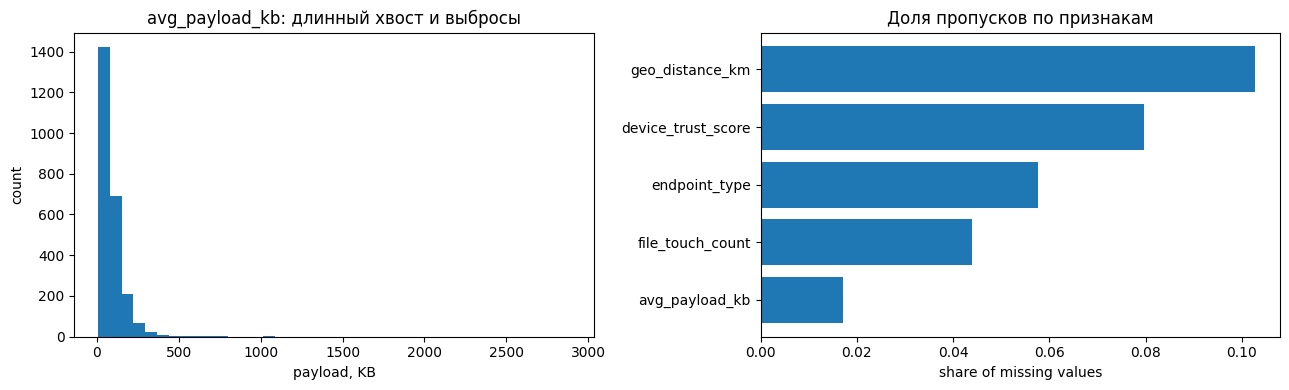

In [5]:

# Короткая визуальная проверка распределений и пропусков.
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(df["avg_payload_kb"].dropna(), bins=40)  # dropna: NaN нельзя отрисовать
axes[0].set_title("avg_payload_kb: длинный хвост и выбросы")
axes[0].set_xlabel("payload, KB")
axes[0].set_ylabel("count")

# Отображаем только признаки, у которых есть хотя бы один пропуск
missing_plot = missing_df.loc[missing_df["missing_share"] > 0, "missing_share"].sort_values(ascending=True)
axes[1].barh(missing_plot.index, missing_plot.values)
axes[1].set_title("Доля пропусков по признакам")
axes[1].set_xlabel("share of missing values")

plt.tight_layout()
plt.show()


## 2. Фиксируем модель и один раз подбираем `C`

Чтобы сравнение было честным, мы **не будем заново тюнить модель под каждый вариант preprocessing**.

Сделаем так:

1. возьмём один reference-вариант  
   (`median imputation + StandardScaler + OneHotEncoder`);
2. подберём для него гиперпараметр `C` через `GridSearchCV` **только на train**;
3. затем это найденное значение `C` зафиксируем для всех остальных вариантов.

Так мы изолируем влияние preprocessing и не смешиваем его с "удачным" подбором гиперпараметров.


In [6]:

# Reference-подбор гиперпараметра C только на train.
# Используем вариант mixed_ohe_standard как «стандартный» reference – он же будет одним из сравниваемых.
# Важно: max_iter=2000 не задан здесь явно – LogisticRegression использует дефолтное C=1.0 при поиске.
# GridSearchCV сам перебирает C из param_grid, переопределяя дефолт через API "model__C".
reference_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            ColumnTransformer(
                transformers=[
                    (
                        "num",
                        Pipeline(
                            steps=[
                                ("imputer", SimpleImputer(strategy="median")),
                                ("scaler", StandardScaler()),
                            ]
                        ),
                        numeric_features,
                    ),
                    (
                        "cat",
                        Pipeline(
                            steps=[
                                ("imputer", SimpleImputer(strategy="most_frequent")),
                                ("encoder", make_ohe()),
                            ]
                        ),
                        categorical_features,
                    ),
                ],
                remainder="drop",
            ),
        ),
        (
            "model",
            LogisticRegression(
                max_iter=2000,   # Увеличено, чтобы lbfgs гарантированно сошёлся
                solver="lbfgs",
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)

# "model__C" – двойное подчёркивание: GridSearchCV умеет передавать параметры в шаги pipeline
param_grid = {"model__C": [0.1, 0.3, 1.0, 3.0, 10.0]}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

grid = GridSearchCV(
    estimator=reference_pipeline,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=cv,
    n_jobs=1,  # Явно указываем однопоточный режим для воспроизводимости
)

grid.fit(X_train, y_train)

best_c = float(grid.best_params_["model__C"])  # Зафиксируем найденное C для всех последующих вариантов

reference_tuning_info = {
    "reference_variant": "mixed_ohe_standard",
    "best_params": grid.best_params_,
    "best_cv_score_roc_auc": float(grid.best_score_),
    "param_grid": param_grid,
    "random_state": RANDOM_STATE,
}

display(pd.DataFrame([reference_tuning_info]))
save_json(reference_tuning_info, ARTIFACTS_DIR / "s07_demo_02_reference_tuning.json")


,reference_variant,best_params,best_cv_score_roc_auc,param_grid,random_state
0,mixed_ohe_standard,{'model__C': 3.0},0.83037,"{'model__C': [0.1, 0.3, 1.0, 3.0, 10.0]}",42


## 3. Варианты preprocessing для сравнения

Мы сравним пять сценариев – при одной и той же модели `LogisticRegression` с одним и тем же `C`.

1. **`numeric_only_standard`**  
   Берём только числовые признаки, категориальные отбрасываются через `remainder="drop"`. Это контрольный вариант: увидим, сколько сигнала теряется, если не работать с категориальными данными вовсе.

2. **`mixed_ohe_no_scaling`**  
   Используем и числовые, и категориальные признаки, но числовые не масштабируем.  
   `LogisticRegression` с L2-регуляризацией штрафует большие по модулю коэффициенты.  
   Признаки с большим диапазоном значений вынуждены иметь маленький коэффициент, чтобы избежать штрафа, – регуляризация фактически давит на одни признаки сильнее других. Ожидаем заметный проигрыш по сравнению с вариантами со scaling.

3. **`mixed_ohe_standard`**  
   Классический честный baseline для линейной модели на mixed-features данных:
   числовые – медианная импутация + `StandardScaler`, категориальные – заполнение модой + `OneHotEncoder`.

4. **`mixed_ohe_robust`**  
   То же, что и предыдущий вариант, но вместо `StandardScaler` используем `RobustScaler`.  
   Ожидаем, что на данных с выбросами (а они у нас есть в `avg_payload_kb` и `session_duration_min`) он
   может дать небольшое преимущество.

5. **`mixed_ordinal_standard`**  
   Категориальные признаки кодируются через `OrdinalEncoder`, то есть каждой категории присваивается целое число.  
   Для линейной модели это **не лучшая идея**: возникает искусственный порядок – например, "mobile" < "vpn" < "corp_lan", – которого в реальности нет. Модель будет интерпретировать разницу между соседними кодами как равнозначную, что неверно.

> **Обратите внимание**: во всех пяти вариантах модель одна и та же. Меняется только preprocessing.


In [7]:

# Описываем и обучаем варианты preprocessing.
variant_descriptions = {
    "numeric_only_standard": "Только числовые признаки: median imputation + StandardScaler; категориальные отбрасываются.",
    "mixed_ohe_no_scaling": "Числовые + категориальные: median imputation + OneHotEncoder; без масштабирования числовых.",
    "mixed_ohe_standard": "Числовые + категориальные: median imputation + StandardScaler + OneHotEncoder.",
    "mixed_ohe_robust": "Числовые + категориальные: median imputation + RobustScaler + OneHotEncoder.",
    "mixed_ordinal_standard": "Числовые + категориальные: median imputation + StandardScaler + OrdinalEncoder.",
}

results = []
fitted_pipelines = {}  # Сохраняем обученные pipeline для последующей диагностики (confusion matrix, коэффициенты)

for variant_name in variant_descriptions:
    pipeline = build_variant(
        name=variant_name,
        numeric_features=numeric_features,
        categorical_features=categorical_features,
        c_value=best_c,  # Одно и то же C для всех вариантов – честное изолированное сравнение
    )
    result, fitted_pipeline = evaluate_pipeline(
        name=variant_name,
        pipeline=pipeline,
        X_train=X_train,
        X_test=X_test,
        y_train=y_train,
        y_test=y_test,
    )
    result["description"] = variant_descriptions[variant_name]  # Добавляем описание для читаемости таблицы

    results.append(result)
    fitted_pipelines[variant_name] = fitted_pipeline

# Сортируем по ROC-AUC (приоритет), затем F1, затем accuracy
results_df = (
    pd.DataFrame(results)
    .sort_values(["roc_auc", "f1", "accuracy"], ascending=False)
    .reset_index(drop=True)
)

results_df.to_csv(ARTIFACTS_DIR / "s07_demo_02_results.csv", index=False)
display(results_df)


,variant,accuracy,f1,roc_auc,n_transformed_features,description
0,mixed_ohe_robust,0.7872,0.575080,0.842111,23,Числовые + категориальные: median imputation +...
1,mixed_ohe_standard,0.7872,0.575080,0.842086,23,Числовые + категориальные: median imputation +...
2,mixed_ohe_no_scaling,0.7872,0.575080,0.842025,23,Числовые + категориальные: median imputation +...
3,mixed_ordinal_standard,0.7456,0.434164,0.785068,11,Числовые + категориальные: median imputation +...
4,numeric_only_standard,0.7504,0.376000,0.710345,6,Только числовые признаки: median imputation + ...


## 4. Сводка результатов

Код ниже выведет два графика и таблицу с дельтами.

**Два графика** показывают:
- сравнение трёх метрик (`accuracy`, `f1`, `roc_auc`) по всем вариантам preprocessing;
- сколько признаков получилось на выходе `ColumnTransformer` у каждого варианта.

**Таблица прироста** показывает разницу между каждым вариантом и базовым `numeric_only_standard`.
Это удобный способ ответить на вопрос: «а сколько именно дало добавление категориальных признаков?»

Что важно читать содержательно:

- если mixed-features варианты заметно сильнее `numeric_only_standard` – категориальные признаки действительно несут сигнал;
- если `OrdinalEncoder` проигрывает `OneHotEncoder` – «псевдопорядок» категорий мешает линейной модели;
- если `mixed_ohe_no_scaling` значительно слабее вариантов со scaling – регуляризация без нормировки признаков действительно работает хуже;
- если `StandardScaler` и `RobustScaler` дают близкий результат, это не значит, что scaling не нужен – это значит, что на данном датасете главный эффект дала структура признаков, а не конкретный способ нормировки.


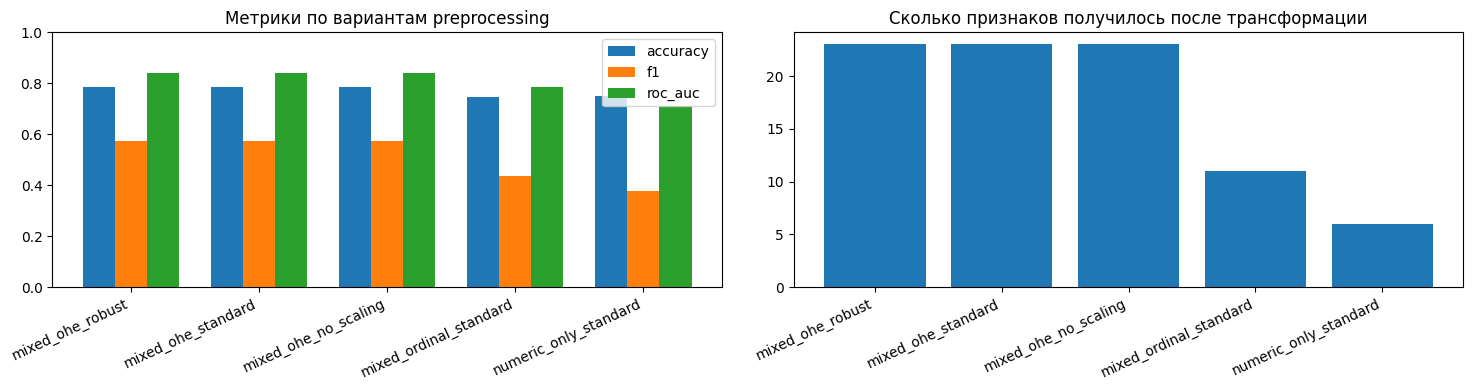

Прирост относительно варианта numeric_only_standard:


,accuracy,f1,roc_auc
variant,,,
mixed_ohe_robust,0.0368,0.1991,0.1318
mixed_ohe_standard,0.0368,0.1991,0.1317
mixed_ohe_no_scaling,0.0368,0.1991,0.1317
mixed_ordinal_standard,-0.0048,0.0582,0.0747
numeric_only_standard,0.0000,0.0000,0.0000


In [8]:

# Визуальное сравнение результатов по метрикам и размерности признакового пространства.
fig, axes = plt.subplots(1, 2, figsize=(15, 4))

metrics_to_plot = ["accuracy", "f1", "roc_auc"]
x = np.arange(len(results_df))
width = 0.25

# Группированная гистограмма: смещаем каждую метрику на ширину столбца, чтобы они не перекрывались
for idx, metric_name in enumerate(metrics_to_plot):
    axes[0].bar(x + (idx - 1) * width, results_df[metric_name], width=width, label=metric_name)

axes[0].set_title("Метрики по вариантам preprocessing")
axes[0].set_xticks(x)
axes[0].set_xticklabels(results_df["variant"], rotation=25, ha="right")
axes[0].set_ylim(0.0, 1.0)
axes[0].legend()

axes[1].bar(results_df["variant"], results_df["n_transformed_features"])
axes[1].set_title("Сколько признаков получилось после трансформации")
axes[1].tick_params(axis="x", rotation=25)
plt.setp(axes[1].get_xticklabels(), ha="right")  # Выравниваем подписи вправо – иначе они перекрываются при повороте

plt.tight_layout()
plt.show()

# Разница по каждой метрике относительно baseline-варианта без категориальных признаков.
# axis=1: вычитаем одну строку (Series) из каждой строки DataFrame.
delta_vs_numeric_only = (
    results_df.set_index("variant")[["accuracy", "f1", "roc_auc"]]
    .subtract(results_df.set_index("variant").loc["numeric_only_standard", ["accuracy", "f1", "roc_auc"]], axis=1)
    .round(4)
)

print("Прирост относительно варианта numeric_only_standard:")
display(delta_vs_numeric_only)


## 5. Детальная диагностика: лучший и более слабые варианты

Возьмём три схемы для подробного сравнения:

- **лучшую** по `ROC-AUC` из числа corrupted-вариантов;
- **`numeric_only_standard`** – осознанно слабый вариант, в котором категориальные признаки отброшены;
- **`mixed_ordinal_standard`** – пример того, как неправильное кодирование категорий ухудшает качество.

Для каждого варианта выведем confusion matrix и classification report.

Confusion matrix показывает **тип ошибок**: какие объекты перепутаны в какую сторону. Для задачи обнаружения аномалий особенно важно смотреть на false negatives (аномалия пропущена) – эта ошибка обычно дороже, чем false positive.

Classification report дополнительно расшифровывает `precision`, `recall` и `f1` по каждому классу отдельно – это полезнее, чем смотреть только на агрегированные метрики.


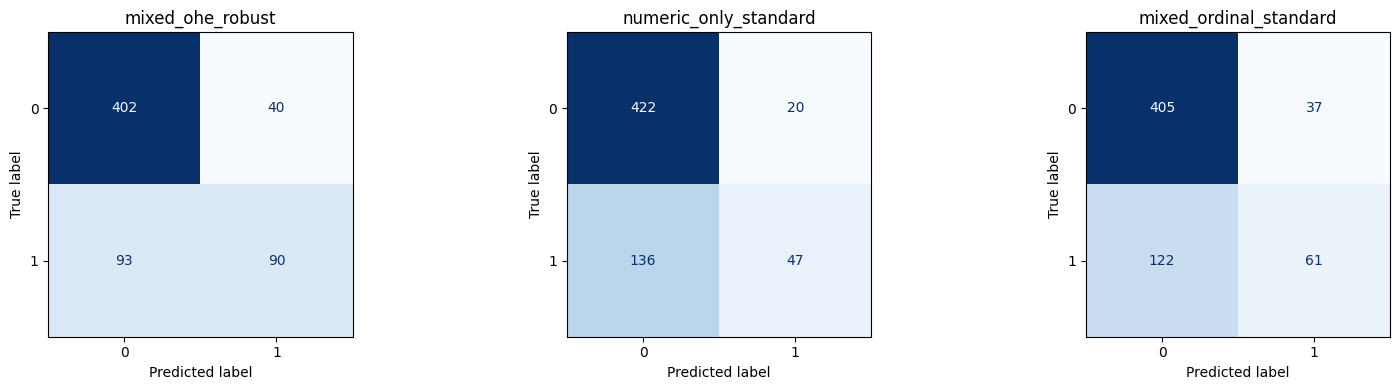


=== Classification report: mixed_ohe_robust ===
              precision    recall  f1-score   support

           0      0.812     0.910     0.858       442
           1      0.692     0.492     0.575       183

    accuracy                          0.787       625
   macro avg      0.752     0.701     0.717       625
weighted avg      0.777     0.787     0.775       625


=== Classification report: numeric_only_standard ===
              precision    recall  f1-score   support

           0      0.756     0.955     0.844       442
           1      0.701     0.257     0.376       183

    accuracy                          0.750       625
   macro avg      0.729     0.606     0.610       625
weighted avg      0.740     0.750     0.707       625


=== Classification report: mixed_ordinal_standard ===
              precision    recall  f1-score   support

           0      0.769     0.916     0.836       442
           1      0.622     0.333     0.434       183

    accuracy            

In [9]:

# Диагностика: confusion matrix и classification report для трёх вариантов.

# После сортировки по roc_auc первая строка – лучший вариант
best_variant = results_df.loc[0, "variant"]
comparison_variants = [best_variant, "numeric_only_standard", "mixed_ordinal_standard"]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# ConfusionMatrixDisplay.from_estimator: внутри сам вызывает pipeline.predict(X_test)
for ax, variant_name in zip(axes, comparison_variants):
    pipeline = fitted_pipelines[variant_name]
    ConfusionMatrixDisplay.from_estimator(
        pipeline,
        X_test,
        y_test,
        ax=ax,
        cmap="Blues",
        colorbar=False,  # Убираем colorbar: он не нужен при наличии числовых значений в ячейках
    )
    ax.set_title(variant_name)

plt.tight_layout()
plt.show()

# classification_report показывает precision, recall и f1 отдельно по каждому классу.
# Для аномалий (класс 1) recall важнее precision: лучше лишний раз проверить, чем пропустить угрозу.
for variant_name in comparison_variants:
    pipeline = fitted_pipelines[variant_name]
    y_pred = pipeline.predict(X_test)
    print(f"\n=== Classification report: {variant_name} ===")
    print(classification_report(y_test, y_pred, digits=3))


## 6. Смотрим внутрь лучшей модели: какие признаки двигают решение

Поскольку мы обучили логистическую регрессию, можно посмотреть на коэффициенты.

Важно помнить:

- коэффициенты интерпретируются **внутри конкретной схемы preprocessing** – у другого варианта они будут другими;
- знак коэффициента показывает направление влияния (положительный → повышает вероятность класса 1);
- величина по модулю отражает **относительную силу** влияния – но только потому, что числовые признаки были масштабированы.

**Ключевое замечание о масштабировании и интерпретируемости:**  
сравнение величин коэффициентов корректно лишь тогда, когда все числовые признаки приведены к сопоставимому масштабу. Без `StandardScaler` признак с диапазоном в тысячи единиц имел бы маленький коэффициент, а признак из диапазона 0–1 – большой, хотя их реальный вклад в предсказание мог быть одинаковым. Масштабирование устраняет этот артефакт единиц измерения.

После `OneHotEncoder` каждый исходный категориальный признак превращается в несколько бинарных колонок – по одной на каждое значение категории. Поэтому в таблице коэффициентов вы увидите, например, `cat__access_channel_public_wifi` и `cat__access_channel_corp_lan` как отдельные признаки.


,feature,coef,abs_coef
0,num__geo_distance_km,1.120823,1.120823
1,cat__access_channel_corp_lan,-0.907331,0.907331
2,num__failed_login_count,0.730956,0.730956
3,cat__mfa_enabled_yes,-0.716491,0.716491
4,num__device_trust_score,-0.686071,0.686071
5,cat__country_risk_high,0.660479,0.660479
6,cat__country_risk_low,-0.656324,0.656324
7,cat__endpoint_type_managed,-0.648392,0.648392
8,cat__access_channel_public_wifi,0.542583,0.542583
9,cat__mfa_enabled_no,0.467170,0.467170


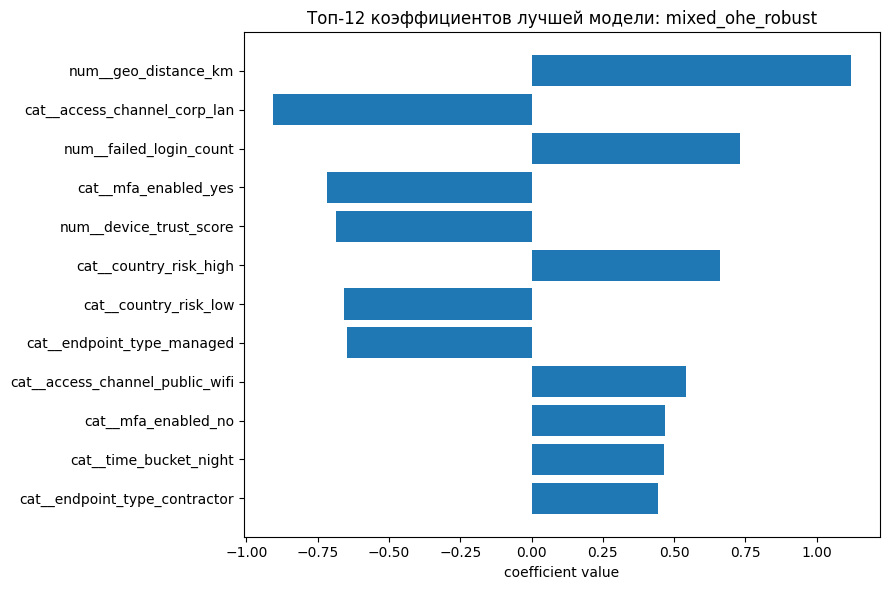

In [10]:

# Коэффициенты лучшей модели.
best_pipeline = fitted_pipelines[best_variant]
best_model = best_pipeline.named_steps["model"]              # sklearn.linear_model.LogisticRegression
best_preprocessor = best_pipeline.named_steps["preprocessor"]  # sklearn.compose.ColumnTransformer

# get_feature_names_out() возвращает имена всех признаков после трансформации.
# Числовые – с префиксом "num__", OHE-признаки – "cat__<колонка>_<значение>".
feature_names = best_preprocessor.get_feature_names_out()

# coef_[0]: для бинарной классификации LogisticRegression хранит один вектор коэффициентов
coef_df = pd.DataFrame(
    {
        "feature": feature_names,
        "coef": best_model.coef_[0],
    }
)
coef_df["abs_coef"] = coef_df["coef"].abs()  # Модуль: абсолютная сила влияния для сортировки
coef_df = coef_df.sort_values("abs_coef", ascending=False).reset_index(drop=True)

coef_df.to_csv(ARTIFACTS_DIR / "s07_demo_02_best_coefficients.csv", index=False)

display(coef_df.head(15))

# iloc[::-1]: разворачиваем для barh – самые сильные признаки оказываются вверху графика
top_plot = coef_df.head(12).iloc[::-1]
plt.figure(figsize=(9, 6))
plt.barh(top_plot["feature"], top_plot["coef"])
plt.title(f"Топ-12 коэффициентов лучшей модели: {best_variant}")
plt.xlabel("coefficient value")
plt.tight_layout()
plt.show()


## 7. Сохраняем артефакты лучшего эксперимента

Сохраним:

- лучшую pipeline-модель целиком (`joblib`);
- JSON с ключевыми метаданными;
- уже сохранённые ранее таблицы результатов и reference-тюнинга.

Это важно, потому что в нормальном инженерном процессе эксперимент не должен заканчиваться картинкой в ноутбуке.


In [11]:

# Сохранение лучшей модели и метаданных.
best_row = results_df.iloc[0].to_dict()
best_pipeline = fitted_pipelines[best_row["variant"]]

# joblib эффективнее pickle для numpy-массивов внутри sklearn-объектов
joblib.dump(best_pipeline, ARTIFACTS_DIR / "s07_demo_02_best_pipeline.joblib")

# float() и int(): pandas возвращает numpy-типы (np.float64, np.int64),
# которые json.dump не умеет сериализовать без явного приведения
best_meta = {
    "best_variant": best_row["variant"],
    "best_metrics": {
        "accuracy": float(best_row["accuracy"]),
        "f1": float(best_row["f1"]),
        "roc_auc": float(best_row["roc_auc"]),
    },
    "n_transformed_features": int(best_row["n_transformed_features"]),
    "numeric_features": numeric_features,
    "categorical_features": categorical_features,
    "reference_best_C": best_c,
    "random_state": RANDOM_STATE,
}

save_json(best_meta, ARTIFACTS_DIR / "s07_demo_02_best_pipeline_meta.json")

print("Сохранены файлы:")
for path in sorted(ARTIFACTS_DIR.glob("s07_demo_02_*")):
    print(" -", path.name)


Сохранены файлы:
 - s07_demo_02_best_coefficients.csv
 - s07_demo_02_best_pipeline.joblib
 - s07_demo_02_best_pipeline_meta.json
 - s07_demo_02_reference_tuning.json
 - s07_demo_02_results.csv


## 8. Итоги

### Что показывает этот эксперимент

- **Категориальные признаки важны.**  
  Если их отбросить, качество заметно проседает даже при аккуратной работе с числовыми признаками.

- **Корректное кодирование категорий не менее важно, чем их наличие.**  
  Для линейной модели `OneHotEncoder` обычно корректнее, чем `OrdinalEncoder`, потому что не навязывает искусственный порядок между несвязанными категориями.

- **Масштабирование числовых признаков влияет на логистическую регрессию.**  
  При L2-регуляризации коэффициенты всех признаков штрафуются одинаково. Без нормировки это несправедливо: признаки с большим диапазоном значений окажутся в невыгодном положении.

- **`ColumnTransformer` – правильный способ работы со смешанными признаками.**  
  Он держит всю логику преобразований внутри единого pipeline, исключает утечку данных из test в train и делает модель воспроизводимой.

- **Разница между `StandardScaler` и `RobustScaler` может быть небольшой.**  
  Это нормальный результат: не каждый эксперимент обязан демонстрировать огромный выигрыш от каждого шага. Здесь главным оказался не выбор скейлера, а сам факт добавления категориальных признаков с правильным кодированием.

- **Preprocessing – часть модели.**  
  Если сравнивать алгоритмы без контроля подготовки признаков, вы сравниваете всё сразу и рискуете сделать неправильный вывод.

### Что стоит попробовать самостоятельно

1. Замените `LogisticRegression` на `RandomForestClassifier`. Изменится ли ранжирование вариантов preprocessing? Почему?

2. Попробуйте закомментировать шаг `("scaler", StandardScaler())` в варианте `mixed_ohe_standard` – как изменится качество и насколько?

3. Увеличьте долю пропусков до 25% в `build_security_like_dataset`. Как это повлияет на разрыв между схемами с разными стратегиями импутации?

4. Посмотрите на `feature_names` после `ColumnTransformer`. Сколько колонок появляется от каждого категориального признака после `OneHotEncoder`? Совпадает ли это с ожидаемым числом категорий?
